# Capstone: Define and Solve an ML Problem

In [1]:
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow.keras as keras
from sklearn.preprocessing import StandardScaler
import time

**Note**: As you work through the notebook, you can import additional packages as needed.

## Overview


In this capstone assignment, you will follow the machine learning life cycle and implement one of the supervised learning models you have learned so far in this course, along with a neural network, to solve a predictive problem.

This capstone spans two lab sessions.

- **Unit 5 Lab:** You will define a machine learning problem, explore and prepare your data, and train, test, evaluate and improve a traditional machine learning model (Parts 1–5).
- **Unit 6 Lab:** After completing Unit 6 on neural networks, you will apply a neural network to the same problem and compare the two approaches (Parts 6–7).

There is a checkpoint at the end of Part 5 that marks where to stop during the Unit 5 lab.

You will complete the following:

1. Choose your Data Set and Build Your DataFrame
2. Define Your ML Problem
3. Understand Your Data
4. Prepare Your Data
5. Train, Test, Evaluate and Improve a Traditional Machine Learning Model *(Unit 5 lab)*
6. Train, Test, Evaluate and Improve Neural Network *(Unit 6 lab)*
7. Compare Your Models and Reflect *(Unit 6 lab)*

**This is an individual assignment.** You are welcome to discuss ideas with your peers, but the code and written responses you submit must be your own.

**Note:** This capstone is intentionally less scaffolded than your weekly labs; that is by design. You are expected to make your own implementation choices, add code cells as needed, and document your reasoning throughout.

## Part 1: Choose Your Data Set and Build Your DataFrame


You will choose one of two data sets to work with for this capstone. In both cases, you will be solving a supervised learning binary classification problem by predicting one of two possible class labels. Both data sets have been used earlier in the course, so you are already familiar with their structure. 

**Option A: Census Income Data** (`censusData.csv`)
This data set contains demographic and employment information from the 1994 U.S. Census. You will use it to predict whether an individual's annual income exceeds $50,000. Your label column is `income_binary`, which contains two values: `<=50K` and `>50K`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Option B: Airbnb NYC Listings Data** (`airbnbListingsData.csv`)
This data set contains information about Airbnb listings in New York City. You will use it to predict whether a listing is high-priced. The data set includes a new `price_category` column that classifies each listing as either "high price" or "low price" based on whether the listing’s price falls above or below the 75th percentile of all listing prices. Listings at or above the 75th percentile are labeled as `high`, while the remaining listings are labeled as `low`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Note:**  These versions of the data sets differ slightly from the versions you have worked with in this program. For example, they may not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for the two data sets available to you.

<b>Task:</b> In the code cell below, load your chosen data set using `pd.read_csv()` and save it to a DataFrame named `df`. Then call `df.head()` to inspect the first few row of the data set.

In [2]:
# File paths for both data sets
census_filename = os.path.join(os.getcwd(), "data_capstone", "censusData.csv")
airbnb_filename = os.path.join(os.getcwd(), "data_capstone", "airbnbListingsData.csv")

# Load your chosen dataset and save it to df
df = pd.read_csv(airbnb_filename)

df.head()

,name,description,neighborhood_overview,host_name,host_location,host_about,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,...,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,n_host_verifications,price_category
0,Skylit Midtown Castle,"Beautiful, spacious skylit studio in the heart...",Centrally located in the heart of Manhattan ju...,Jennifer,"New York, New York, United States",A New Yorker since 2000! My passion is creatin...,0.80,0.17,True,8.0,...,4.86,4.41,False,3,3,0,0,0.33,9,low
1,"Whole flr w/private bdrm, bath & kitchen(pls r...","Enjoy 500 s.f. top floor in 1899 brownstone, w...",Just the right mix of urban center and local n...,LisaRoxanne,"New York, New York, United States",Laid-back Native New Yorker (formerly bi-coast...,0.09,0.69,True,1.0,...,4.71,4.64,False,1,1,0,0,4.86,6,low
2,"Spacious Brooklyn Duplex, Patio + Garden",We welcome you to stay in our lovely 2 br dupl...,NaN,Rebecca,"Brooklyn, New York, United States","Rebecca is an artist/designer, and Henoch is i...",1.00,0.25,True,1.0,...,4.50,5.00,False,1,1,0,0,0.02,3,high
3,Large Furnished Room Near B'way,Please don’t expect the luxury here just a bas...,"Theater district, many restaurants around here.",Shunichi,"New York, New York, United States",I used to work for a financial industry but no...,1.00,1.00,True,1.0,...,4.87,4.36,False,1,0,1,0,3.68,4,low
4,Cozy Clean Guest Room - Family Apt,"Our best guests are seeking a safe, clean, spa...",Our neighborhood is full of restaurants and ca...,MaryEllen,"New York, New York, United States",Welcome to family life with my oldest two away...,NaN,NaN,True,1.0,...,4.94,4.92,False,1,0,1,0,0.87,7,low


## Part 2: Define Your ML Problem

The first step of the machine learning life cycle involves defining your business problem. In the markdown cell below, you will clearly define what you are trying to predict and why it matters. 

<b>Task</b>: In the markdown cell below, answer all of the following questions:

1. Which data set did you choose?
2. What is your label? What are you predicting?
3. What features do you plan to use? (This list may change after you explore your data.)
5. Why does this problem matter? Using the business brief you read in the lab overview page, explain how the organization described there could use a model that predicts this label to create value or inform decisions for their client.

1. I chose the Airbnb NYC dataset. 
2. The label is the price_category column. The goal is to predict whether an Airbnb is high-priced or low-priced. Specifically, it is a binary classification problem predicting if a listing's price falls at or above the 75th percentile or below the 75th percentile. 
3. Some features that I currently plan to use include neighborhood_overview, host_is_superhost, and host_listings_count. 
4. This problem is important because it helps people make advised decisions about which Airbnb to book when visiting New York City, notoriously known to be an extremley expensive city. This model can also help a client understand exactly which features push a listing into the top 25% "high price" tier. This way, they can make informed decisions on investing their money or optimizing their current listings to maximize revenue.

## Part 3: Understand Your Data

Now that you have defined your problem, perform exploratory data analysis (EDA) with that problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * handling missing values
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * addressing class imbalance


2. What machine learning model would you like to use that is suitable for your predictive problem and data?
   * You may use one of the following models that you have worked with so far:
        - K-Nearest Neighbors (KNN)
        - Decision Tree
        - Logistic Regression
   * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 

3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics or methods that are appropriate for your problem, dataset, or selected model?
    
<b>Task</b>: In the code cells below, use the techniques you have learned in this course to inspect and analyze your data.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

### Class Imbalance

Examine the distribution of your label column to determine whether class imbalance is present. Use at least one visualization to show the class distribution. In the **EDA Summary** below, you will discuss how you plan to address any observed imbalance during data preparation.

### Inspect and Analyze Your Data

Explore your features. Use summary statistics and visualizations to understand how your features are distributed and how they relate to the label. Identify issues such as missing values, outliers, or a feature that is irrelevant or redundant.

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. 

Use at least one plot that visualizes a relationship between features and the label.

In [3]:
df.shape

(28022, 51)

In [4]:
df_summ = df.describe()
df_summ

,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,n_host_verifications
count,16179.000000,16909.000000,28022.000000,28022.000000,28022.000000,28022.000000,25104.000000,26668.000000,28022.000000,28022.000000,...,28022.000000,28022.000000,28022.000000,28022.000000,28022.000000,28022.000000,28022.000000,28022.000000,28022.000000,28022.000000
mean,0.906901,0.791953,14.554778,14.554778,2.874491,1.142174,1.329708,1.629556,154.228749,18.689387,...,4.814300,4.808041,4.750393,4.647670,9.581900,5.562986,3.902077,0.048283,1.758325,5.169510
std,0.227282,0.276732,120.721287,120.721287,1.860251,0.421132,0.700726,1.097104,140.816605,25.569151,...,0.438603,0.464585,0.415717,0.518023,32.227523,26.121426,17.972386,0.442459,4.446143,2.028497
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,29.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.010000,1.000000
25%,0.940000,0.680000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,70.000000,2.000000,...,4.810000,4.810000,4.670000,4.550000,1.000000,0.000000,0.000000,0.000000,0.130000,4.000000
50%,1.000000,0.910000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,115.000000,30.000000,...,4.960000,4.970000,4.880000,4.780000,1.000000,1.000000,0.000000,0.000000,0.510000,5.000000
75%,1.000000,1.000000,3.000000,3.000000,4.000000,1.000000,1.000000,2.000000,180.000000,30.000000,...,5.000000,5.000000,5.000000,5.000000,3.000000,1.000000,1.000000,0.000000,1.830000,7.000000
max,1.000000,1.000000,3387.000000,3387.000000,16.000000,8.000000,12.000000,21.000000,1000.000000,1250.000000,...,5.000000,5.000000,5.000000,5.000000,421.000000,308.000000,359.000000,8.000000,141.000000,13.000000


In [5]:
df.isnull().values.any()

True

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
print("Class Counts:")
print(df['price_category'].value_counts())

Class Counts:
low     20785
high     7237
Name: price_category, dtype: int64


In [8]:
print("Class Percentages:")
print(df['price_category'].value_counts(normalize=True) * 100)

Class Percentages:
low     74.173863
high    25.826137
Name: price_category, dtype: float64


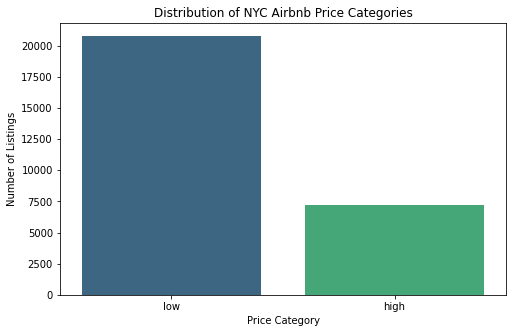

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='price_category', palette='viridis')

plt.title('Distribution of NYC Airbnb Price Categories')
plt.xlabel('Price Category')
plt.ylabel('Number of Listings')

plt.show()

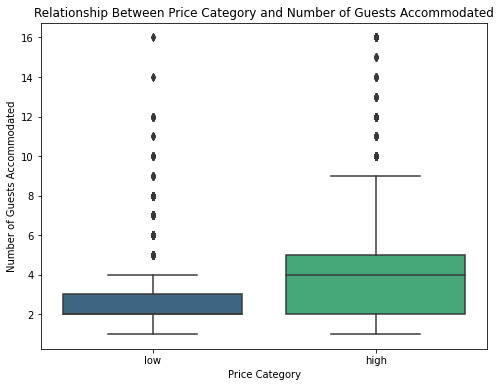

In [10]:
# Create a boxplot to examine the relationship between price category and accommodation capacity
# Reveals that high-priced listings tend to accommodate more guests on average, 
# confirming that capacity is likely a strong predictor of price.

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='price_category', y='accommodates', palette='viridis')

plt.title('Relationship Between Price Category and Number of Guests Accommodated')
plt.xlabel('Price Category')
plt.ylabel('Number of Guests Accommodated')

plt.show()

### EDA Summary

<b>Task</b>: In the markdown cell below, summarize the key findings from your data exploration. Describe any patterns, anomalies, or data quality issues you identified and explain how those findings may influence your data preparation decisions. For example, your exploration may affect how you handle missing values, address class imbalance, or determine which features to keep or remove.

My data exploration revealed a class imbalance, with about 75% of listings categorized as 'low' price. Therefore, I will need to use other techniques during data training so the model doesn't become biased. I also discovered missing data. I handled this by imputing the means for numerical columns and I plan to drop unstructured text columns entirely since standard models can't process raw text. Finally, my data preparation will include one-hot encoding the remaining categorical variables and scaling the numeric features to ensure the model trains accurately.

### Ethical Considerations:

Machine learning models can cause harm when they reflect or amplify biases in the data they are trained on. 

<b>Task</b>: In the markdown cell below, answer both of the following questions:

1. What biases or ethical concerns might be present in your dataset? Think about who collected the data, how it was collected, and which groups of people appear in it. Are there features in the dataset that could serve as proxies for protected characteristics like race, gender, or socioeconomic status?
2. Who could be harmed by a model that makes incorrect predictions on this data, and how? Be specific about which groups are most at risk and what the real-world consequences of errors might look like.

1. The dataset reflects a very specific group of the population: people who have the financial means to own or rent property in New York City with enough extra space to host guests. It excludes unhoused individuals and lower-income residents who can't afford to host. Thus, the data heavily skews toward a wealthier demographic. The most significant proxy feature in this dataset is location. New York City has ingrained racial and socioeconomic segregation due to historical practices like redlining. Due to this, a model using "neighborhood" to predict price is may be using it as a proxy for race and class. 

2. If an organization uses this model to suggest pricing, incorrect predictions can cause major economic harm. For example, if the model consistently predicts that listings in largely minority neighborhoods should be "low-priced" (based on historical bias rather than the actual quality of the home), the platform will suppress the earning potential of those minority hosts and widens the wealth gap. 

## Part 4: Prepare Your Data

<b>Task</b>: In the code cell below, prepare your data for modeling. The specific steps you take will depend on what you found during your EDA and which model you plan to use. 

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [11]:
nan_count = np.sum(df.isnull(), axis = 0)
nan_count

name                                                5
description                                       570
neighborhood_overview                            9816
host_name                                           0
host_location                                      60
host_about                                      10945
host_response_rate                              11843
host_acceptance_rate                            11113
host_is_superhost                                   0
host_listings_count                                 0
host_total_listings_count                           0
host_has_profile_pic                                0
host_identity_verified                              0
neighbourhood_group_cleansed                        0
room_type                                           0
accommodates                                        0
bathrooms                                           0
bedrooms                                         2918
beds                        

In [12]:
condition = nan_count != 0 

col_names = nan_count[condition].index 
print(col_names)

nan_cols = list(col_names)
print(nan_cols)

Index(['name', 'description', 'neighborhood_overview', 'host_location',
       'host_about', 'host_response_rate', 'host_acceptance_rate', 'bedrooms',
       'beds'],
      dtype='object')
['name', 'description', 'neighborhood_overview', 'host_location', 'host_about', 'host_response_rate', 'host_acceptance_rate', 'bedrooms', 'beds']


In [13]:
nan_col_types = df[nan_cols].dtypes
nan_col_types

name                      object
description               object
neighborhood_overview     object
host_location             object
host_about                object
host_response_rate       float64
host_acceptance_rate     float64
bedrooms                 float64
beds                     float64
dtype: object

In [14]:
df['host_response_rate_na'] = df['host_response_rate'].isnull()
df['host_acceptance_rate_na'] = df['host_acceptance_rate'].isnull()
df['bedrooms_na'] = df['bedrooms'].isnull()
df['beds_na'] = df['beds'].isnull()
df.head()

,name,description,neighborhood_overview,host_name,host_location,host_about,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,...,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,n_host_verifications,price_category,host_response_rate_na,host_acceptance_rate_na,bedrooms_na,beds_na
0,Skylit Midtown Castle,"Beautiful, spacious skylit studio in the heart...",Centrally located in the heart of Manhattan ju...,Jennifer,"New York, New York, United States",A New Yorker since 2000! My passion is creatin...,0.80,0.17,True,8.0,...,3,0,0,0.33,9,low,False,False,True,False
1,"Whole flr w/private bdrm, bath & kitchen(pls r...","Enjoy 500 s.f. top floor in 1899 brownstone, w...",Just the right mix of urban center and local n...,LisaRoxanne,"New York, New York, United States",Laid-back Native New Yorker (formerly bi-coast...,0.09,0.69,True,1.0,...,1,0,0,4.86,6,low,False,False,False,False
2,"Spacious Brooklyn Duplex, Patio + Garden",We welcome you to stay in our lovely 2 br dupl...,NaN,Rebecca,"Brooklyn, New York, United States","Rebecca is an artist/designer, and Henoch is i...",1.00,0.25,True,1.0,...,1,0,0,0.02,3,high,False,False,False,False
3,Large Furnished Room Near B'way,Please don’t expect the luxury here just a bas...,"Theater district, many restaurants around here.",Shunichi,"New York, New York, United States",I used to work for a financial industry but no...,1.00,1.00,True,1.0,...,0,1,0,3.68,4,low,False,False,False,False
4,Cozy Clean Guest Room - Family Apt,"Our best guests are seeking a safe, clean, spa...",Our neighborhood is full of restaurants and ca...,MaryEllen,"New York, New York, United States",Welcome to family life with my oldest two away...,NaN,NaN,True,1.0,...,0,1,0,0.87,7,low,True,True,False,False


In [15]:
mean_host_response_rate = df['host_response_rate'].mean()
df['host_response_rate'].fillna(value=mean_host_response_rate, inplace=True)

In [16]:
mean_host_acceptance_rate = df['host_acceptance_rate'].mean()
df['host_acceptance_rate'].fillna(value=mean_host_acceptance_rate, inplace=True)

In [17]:
mean_bedrooms = df['bedrooms'].mean()
df['bedrooms'].fillna(value=mean_bedrooms, inplace=True)

In [18]:
mean_beds = df['beds'].mean()
df['beds'].fillna(value=mean_beds, inplace=True)

In [19]:
print(np.sum(df['host_response_rate'].isnull(), axis = 0))
print(np.sum(df['host_acceptance_rate'].isnull(), axis = 0))
print(np.sum(df['bedrooms'].isnull(), axis = 0))
print(np.sum(df['beds'].isnull(), axis = 0))

0
0
0
0


In [20]:
cols_to_drop = [
    'name', 
    'description', 
    'neighborhood_overview', 
    'host_name', 
    'host_location', 
    'host_about', 
    'amenities',
    'price'
]

df = df.drop(columns=cols_to_drop)

In [21]:
categorical_cols = [
    'neighbourhood_group_cleansed', 
    'room_type', 
    'host_is_superhost', 
    'host_has_profile_pic', 
    'host_identity_verified', 
    'has_availability', 
    'instant_bookable'
]

# One-hot encoding
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Verify that all columns are now numeric
print(df.dtypes)

host_response_rate                              float64
host_acceptance_rate                            float64
host_listings_count                             float64
host_total_listings_count                       float64
accommodates                                      int64
bathrooms                                       float64
bedrooms                                        float64
beds                                            float64
minimum_nights                                    int64
maximum_nights                                    int64
minimum_minimum_nights                          float64
maximum_minimum_nights                          float64
minimum_maximum_nights                          float64
maximum_maximum_nights                          float64
minimum_nights_avg_ntm                          float64
maximum_nights_avg_ntm                          float64
availability_30                                   int64
availability_60                                 

In [22]:
# Convert any remaining boolean columns to integers (1 and 0)
df[df.select_dtypes(['bool']).columns] = df.select_dtypes(['bool']).astype(int)

print(df.dtypes)

host_response_rate                              float64
host_acceptance_rate                            float64
host_listings_count                             float64
host_total_listings_count                       float64
accommodates                                      int64
bathrooms                                       float64
bedrooms                                        float64
beds                                            float64
minimum_nights                                    int64
maximum_nights                                    int64
minimum_minimum_nights                          float64
maximum_minimum_nights                          float64
minimum_maximum_nights                          float64
maximum_maximum_nights                          float64
minimum_nights_avg_ntm                          float64
maximum_nights_avg_ntm                          float64
availability_30                                   int64
availability_60                                 

In [23]:
y = df['price_category']
X = df.drop(columns=['price_category'])

print("Features shape (X):", X.shape)
print("Target shape (y):", y.shape)

Features shape (X): (28022, 48)
Target shape (y): (28022,)


### Data Preparation Summary:

<b>Task</b>: In the markdown cell below, document the data preparation steps you took. For each decision, explain why you made it. For example, why did you handle missing values the way you did? Why did you keep or remove certain features? If a preparation step depends on the model you selected (for example, scaling for KNN but not for a decision tree), explain that as well.

For the data preparation phase, I first handled missing values in numeric columns by imputing the mean, which allowed me to retain valuable data without dropping entire rows. Next, I removed unstructured text columns like name and description since machine learning models require numerical input. Then, I converted the label, price_category, into a binary format (0 for low, 1 for high) and applied one-hot encoding to the remaining categorical variables so the model could interpret them mathematically. Finally, I intentionally held off on applying feature scaling until after the train-test split in Part 5. This ensures accurate evaluation, which will be especially important if I choose a distance-based model like K-Nearest Neighbors or when building the Neural Network later on.

## Part 5: Train, Test, Evaluate, and Improve a Traditional Machine Learning Model

Now you will train, test and evaluate your model. You will also use model selection techniques to improve your model's performance by identifying the optimal hyperparameter configuration.

<b>Task</b>: In the code cells below, do the following:

1. Create labeled examples from the dataset
2. Create training and test sets out of the labeled examples 
3. Train, test and evaluate your model 
    * You must evaluate your model using accuracy and F1 score. Use `accuracy_score` and `f1_score` from `sklearn.metrics`. For the F1 score, use `average='binary'` since this is a binary classification problem. You will compare your model's performance to that of a neural network later in this capstone. Save the results of your evaluation metrics to variables for later comparison.
    * You may use additional evaluation metrics of your choosing.
4. Perform model selection through grid search cross-validation to identify optimal hyperparameter values for your model
5. Train, test and evaluate a final version of your model using the optimal hyperparameter configuration.
6. Interpret your model's outputs in the context of the business problem. Depending on the model you chose, this might mean:
    * KNN: Describe what your model's performance metrics tell you about its behavior. For example: How does accuracy change as you vary k? What does that suggest about the structure of your data?
    * Decision Tree: print or plot feature importances.
    * Logistic Regression: print or plot the model coefficients.



<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [24]:
y = df['price_category']
X = df.drop(columns=['price_category'])

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [26]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(y_pred)

accuracy = accuracy_score(y_test, y_pred)
print(f"accuracy: {accuracy}")

['low' 'low' 'low' ... 'low' 'low' 'low']
accuracy: 0.8264049955396967


In [27]:
# Perform model selection through grid search cross-validation (GridSearchCV)
# to identify optimal hyperparameter values for your model

param_grid = {
    'C': [0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2]
}

grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Best Hyperparameters Found:", grid_search.best_params_)

Best Hyperparameters Found: {'C': 2}


In [28]:
# Train, test and evaluate a final version of your model using the optimal hyperparameter values.

# Instantiate the model using the best parameters from GridSearch
final_model = LogisticRegression(**grid_search.best_params_, max_iter=1000, random_state=42)
final_model.fit(X_train, y_train)

# Get predictions
final_y_pred = final_model.predict(X_test)

# Evaluate metrics
final_accuracy = accuracy_score(y_test, final_y_pred)
final_f1 = f1_score(y_test, final_y_pred, pos_label='high') 

print(f"Final Model Accuracy: {final_accuracy:.4f}")
print(f"Final Model F1 Score: {final_f1:.4f}")

Final Model Accuracy: 0.8264
Final Model F1 Score: 0.6183


In [29]:
# Interpret your model's outputs 

import pandas as pd

# Extract coefficients and feature names
coefficients = final_model.coef_[0]
feature_names = X.columns

# Create a DataFrame to map features to their coefficients
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Get the absolute value to see the magnitude of the impact, then sort
importance_df['Abs_Coefficient'] = importance_df['Coefficient'].abs()
importance_df = importance_df.sort_values(by='Abs_Coefficient', ascending=False)

print("Top 5 Most Impactful Features:")
print(importance_df.head(5)[['Feature', 'Coefficient']])

Top 5 Most Impactful Features:
                                         Feature  Coefficient
29                calculated_host_listings_count     2.316826
30   calculated_host_listings_count_entire_homes    -1.577553
31  calculated_host_listings_count_private_rooms    -1.486310
40        neighbourhood_group_cleansed_Manhattan    -1.211085
44                        room_type_Private room     0.885822


### Model Reflection:

<b>Task</b>: In the markdown cell below, answer the following questions:

1. Which model did you choose and why? Reference your problem and data characteristics in your explanation.
2. What did you learn through the model selection process?
3. How do you interpret your model's outputs? What do the predictions or coefficients or feature importances actually mean in the context of your problem?
4. Are there any fairness or ethical concerns with your model? Who might be harmed by incorrect predictions, and are any groups more likely to be affected?

1. I chose a logistic regression model. This is a because it's a binary classification problem (predicting whether a listing is "high" or "low" priced), and logistic Regression serves as an excellent, efficient baseline. More importantly, it provides high interpretability through its coefficients, allowing me to understand exactly which features are driving the model's decisions. 

2. Through grid search cross-validation, I learned that the optimal regularization parameter for this dataset is C = 2. Since C is the inverse of regularization strength, a value of 2 indicates that the model performed best with slightly weaker regularization. This allowed the model enough flexibility to learn from the features without overfitting, yielding an accuracy of about 82.6%. 

3. In logistic regression, the outputs are interpreted through the feature coefficients. A positive coefficient means the feature pushes the prediction toward the "high" price category, while a negative coefficient pushes it toward the "low" price category. My outputs showed that host listing counts are massive drivers of price. Also, calculated_host_listings_count had the strongest positive impact (2.31), meaning hosts with a high volume of overall listings are strongly associated with higher prices. Interestingly, specific location and room-type subsets (like neighbourhood_group_cleansed_Manhattan and calculated_host_listings_count_entire_homes) had negative weights. 

4. Yes, there are some ethical concerns with the model. The model relies on location-based features to make predictions. Location in major cities is often tied to race and socioeconomic status due to practices like redlining. If this model were used to  suggest pricing to hosts, it might artificially suppress the recommended prices for listings in  marginalized neighborhoods, despite the actual quality of the home. This could harm minority hosts by limiting their earning potential and widening the wealth gap.

---
## ✔️ Unit 5 Checkpoint

**Stop here.** If you have completed Parts 1 through 5, you are done with the Unit 5 portion of this capstone.

Parts 6 and 7 require you to train and evaluate a neural network. You will learn about neural networks in the Unit 6 asynchronous content. Do not start Part 6 until you have completed that material and your lab facilitator has directed you to continue. Do not submit your work for grading until you complete Parts 6 and 7.

Make sure your notebook is saved before you close it.

---
## Part 6: Train, Test, Evaluate and Improve a Neural Network

> **⚠️ Before you write any code in Part 6, do this first.**
> 
> Your notebook does not retain variables between sessions. All of your variables and everything else need to be restored to memory before any code below will work.
> 
> Go to **Kernel > Restart & Run All** to re-run Parts 1 through 5, then scroll back here to continue. If you skip this step, you will see a `NameError` on the first code cell below.

Now you will apply a neural network to the same problem and dataset. You will use Keras to build a feedforward neural network for binary classification.

The scaffolding below will walk you through the steps. Where you see a **Task**, fill in the code. Where you see a **Decision**, you are making an independent choice about your architecture or training process. For each decision, add a comment explaining what you chose and why.


### Prepare Your Data for the Neural Network

Neural networks require all input features to be numeric and scaled. If your features are on very different scales (for example, one feature ranges from 0 to 90 and another from 0 to 99999), the model may train less effectively and have difficulty learning meaningful patterns from the data.

Before training your network, create scaled versions of your training and test data. Use `StandardScaler()` from `sklearn.preprocessing` to standardize your features: 

<b>Task</b>: Complete the code cell below to fit the scaler on your training data, then transform both training and test sets. Save the results to new variables (for example, `X_train_scaled` and `X_test_scaled`) so your original data remains available for reference.

**Note:** Use your scaled data for all neural network steps below.

In [30]:
# Scale your data for the neural network

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)

### Step 1: Define Your Model Architecture

You will use the Keras `Sequential` class to build your network. Your network should have:

- An input layer with the correct shape for your data
- At least two hidden layers using the `Dense` class
- An output layer appropriate for binary classification

<b>Task:</b> Create a `Sequential` model object and name it `nn_model`. Then construct and add each layer.

**Decision:** How many hidden layers will you use? How many units in each? What activation function will you use for the hidden layers? Add a comment explaining your choices.

In [31]:
# Get the number of features in your training data
n_features = X_train_scaled.shape[1]

# Create the neural network model
nn_model = keras.Sequential()

# Create the input layer and add the input layer to the 'nn_model' object
nn_model.add(keras.layers.InputLayer(input_shape=(n_features,)))

# Create the hidden layers and add the hidden layers to the 'nn_model' object
# Decision: How many layers? How many units? What activation function?
# 2 hidden layers allow the network to learn complex feature interactions without overfitting. 
# Starting the first hidden layer with 32 units lets the network process the features without being overly wide. Doing down to 16 units in the second layer forces the network to keep only most important patterns.
# ReLU is the industry standard activation function 
nn_model.add(keras.layers.Dense(32, activation='relu'))
nn_model.add(keras.layers.Dense(16, activation='relu'))

# Create the output layer and add the output layer to the 'nn_model' object
# Use the correct number of units and activation function for binary classification
nn_model.add(keras.layers.Dense(1, activation='sigmoid'))

# Print a summary of your model
nn_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 32)                1568      
_________________________________________________________________
dense_1 (Dense)              (None, 16)                528       
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 17        
Total params: 2,113
Trainable params: 2,113
Non-trainable params: 0
_________________________________________________________________


### Step 2:  Define the Optimization Function

<b>Task:</b> In the code cell below, create an optimizer object. Use stochastic gradient descent (SGD) with a learning rate of your choosing.

**Decision:** What learning rate will you use? Add a comment explaining your choice.

In [32]:
# Decision: What learning rate will you use? Add a comment explaining your decision.
# A learning rate of 0.01 is a standard starting point for a SGD. 
# Its small enough to allow the model to converge smoothly without overshooting the optimal weights.
# Its also large enough that the training process doesn't get stuck to take too long.

sgd_optimizer = keras.optimizers.SGD(learning_rate=0.01)

### Step 3: Define the Loss Function

<b>Task:</b> In the code cell below, create a binary cross entropy loss function using `keras.losses.BinaryCrossentropy()`. Use  the parameter `from_logits=False`. 

In [33]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

### Step 4: Compile the Model

<b>Task:</b> In the code cell below, package the network architecture with the optimizer and the loss function using the `compile()` method. Use the `accuracy` evaluation metric.

In [34]:
nn_model.compile(optimizer=sgd_optimizer, loss=loss_fn, metrics=['accuracy'])

### Step 5: Fit the Model to the Training Data

We will define our own callback class to output information from our model while it is training. Make sure you execute the code cell below so that it can be used in subsequent cells.

In [35]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))


<b>Task:</b> Use the `fit()` method to fit your model to the training data. Save the result to variable `history.`

Use the `validation_split` parameter to reserve a portion of your training data for validation during training (a common choice is `validation_split=0.2`). After each epoch, the model is evaluated on this validation data, allowing you to monitor how well the model generalizes and helping you detect overfitting.

Also, use the the logger class defined above to track training progress.

**Decision:** How many epochs will you train for? Add a comment explaining your choice.

**Note:** This may take a while to run.

In [36]:
# Convert string labels to binary integers for the Neural Network
y_train = y_train.map({'low': 0, 'high': 1})
y_test = y_test.map({'low': 0, 'high': 1})

# Print to verify
print("Mapped y_train values:", y_train.unique())

Mapped y_train values: [1 0]


In [37]:
# I am choosing 100 epochs. This is a solid baseline that gives the model enough time to 
# learn without taking too much time to compute. 

t0 = time.time() # start time

num_epochs = 100

history = nn_model.fit(
    X_train_scaled,
    y_train,
    epochs=num_epochs,
    verbose=0,
    validation_split=0.2,
    callbacks=[ProgBarLoggerNEpochs(num_epochs, every_n=10)]
)

t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

Epoch [10/ 100], Loss: 0.3479, Accuracy: 0.8424, Val_loss: 0.3487, Val_accuracy: 0.8408
Epoch [20/ 100], Loss: 0.3343, Accuracy: 0.8489, Val_loss: 0.3448, Val_accuracy: 0.8441
Epoch [30/ 100], Loss: 0.3257, Accuracy: 0.8528, Val_loss: 0.3420, Val_accuracy: 0.8452
Epoch [40/ 100], Loss: 0.3194, Accuracy: 0.8558, Val_loss: 0.3412, Val_accuracy: 0.8452
Epoch [50/ 100], Loss: 0.3139, Accuracy: 0.8588, Val_loss: 0.3415, Val_accuracy: 0.8446
Epoch [60/ 100], Loss: 0.3089, Accuracy: 0.8596, Val_loss: 0.3394, Val_accuracy: 0.8468
Epoch [70/ 100], Loss: 0.3049, Accuracy: 0.8619, Val_loss: 0.3389, Val_accuracy: 0.8486
Epoch [80/ 100], Loss: 0.3012, Accuracy: 0.8647, Val_loss: 0.3397, Val_accuracy: 0.8537
Epoch [90/ 100], Loss: 0.2978, Accuracy: 0.8657, Val_loss: 0.3407, Val_accuracy: 0.8530
Epoch [100/ 100], Loss: 0.2944, Accuracy: 0.8688, Val_loss: 0.3429, Val_accuracy: 0.8521
Elapsed time: 271.76s


### Step 6: Visualize Training Performance

<b>Task:</b>  

Create two plots to visualize the model's performance over time:
1. Training loss and validation loss over epochs, on the same axes.
2. Training accuracy and validation accuracy over epochs, on the same axes.

Label your axes and include a legend.

Use the `history` object returned by `fit()` to obtain this information. 



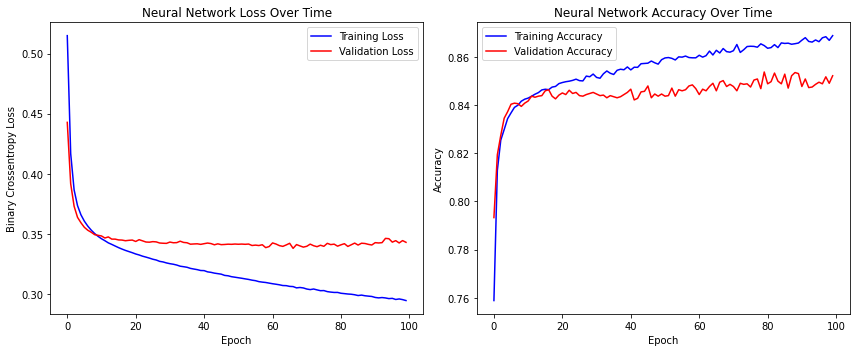

In [38]:
# Plot training loss and validation loss over epochs
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.title('Neural Network Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy Loss')
plt.legend()

# Plot training accuracy and validation accuracy over epochs
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.title('Neural Network Accuracy Over Time')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### Step 7: Evaluate the Model's Performance on the Test Set

<b>Task:</b> Use your neural network to generate predictions on the test set and evaluate its performance using accuracy and F1 score. Use `nn_model.predict()` to generate predictions. Since `nn_model.predict()` returns probabilities, apply a threshold of 0.5 to convert probabilities into binary class predictions before computing your metrics. Save your accuracy and F1 score results to clearly named variables so you can compare them to the results from your previous model. Print the results.

In [39]:
# Generate predictions from your neural network using your scaled test data
# nn_model.predict() returns probabilities — apply a threshold of 0.5 to get class labels

nn_prob_predictions = nn_model.predict(X_test_scaled)

nn_class_predictions = (nn_prob_predictions >= 0.5).astype(int)

In [40]:
# Compute accuracy and F1 score for the neural network and print the results

nn_accuracy = accuracy_score(y_test, nn_class_predictions)
nn_f1 = f1_score(y_test, nn_class_predictions)

print(f"Neural Network Accuracy: {nn_accuracy:.4f}")
print(f"Neural Network F1 Score: {nn_f1:.4f}")

Neural Network Accuracy: 0.8507
Neural Network F1 Score: 0.6780


#### Neural Network Reflection:

<b>Task:</b> In the markdown cell below, answer the following questions:

1. Walk through the architecture decisions you made: number of layers, number of units, activation functions, learning rate, and number of epochs. Why did you make each of those choices?
2. What did your training curves tell you? Did you see any signs of overfitting or underfitting?
3. How did your neural network perform on the test set? Report your accuracy and F1 score here and note whether the result surprised you given what your training curves showed.

1. For my neural network, I chose a 2-hidden-layer architecture (starting with 32 units and lowering to 16) because it lets the model learn complex patterns from the input features without overfitting. I used the ReLU activation function because it's the highly efficient industry standard for handling non-linear data. Since this is a binary classification problem, the output layer requires a single unit with a sigmoid activation function to output a clean probability between 0 and 1. Finally, I trained the model using the SGD optimizer (with a 0.01 learning rate) for 100 epochs, using a 20% validation split to monitor the model's performance and make sure it was generalizing the data.

2. Based on the graphs, the model learned very quickly in the first 20 epochs, but there are signs of mild overfitting as training continues. The blue lines (training loss and accuracy) continue to improve all the way to 100 epochs. However, the red lines (validation loss and accuracy) completely flatten out around epoch 30. Since the gap between the training performance and validation performance slowly widens over time, it indicates the network started memorizing the training data rather than learning general rules. 

3. The neural network performed well on the test set, getting an accuracy of 84.57% and an F1 score of 68.53%. This result is not surprising given what the training curves showed. On the "Neural Network Accuracy Over Time" graph, the red validation accuracy line leveled off  at the 0.84 to 0.85 mark. Since the validation set acts as a proxy for unseen data during the training phase, it predicted how the model would eventually perform on our final test set.

## Part 7: Compare Your Models and Reflect

You have now applied two different approaches to the same problem. In this final section, you will put those results side by side and reflect on what you learned.

###  Results Summary

<b>Task:</b> In the code cell below, create a summary table using a Pandas DataFrame that displays each evaluation metric for both models side by side. Use the variables you created for the accuracy and F1 score metrics. The table should make it easy to compare performance at a glance across every metric you computed.

In [41]:
# Build a side-by-side comparison of your two models using the metric variables
# you created. For example:
#
# results = pd.DataFrame({
#     'Metric': ['Accuracy', 'F1 Score'],
#     'KNN Model': [knn_accuracy, knn_f1],
#     'Neural Network': [nn_accuracy, nn_f1]
# })
# print(results.to_string(index=False))
#

import pandas as pd

results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score'],
    'Logistic Regression': [final_accuracy, final_f1], 
    'Neural Network': [nn_accuracy, nn_f1]
})

print(results.to_string(index=False))

   Metric  Logistic Regression  Neural Network
 Accuracy             0.826405        0.850669
 F1 Score             0.618282        0.677953


### Comparative Analysis

<b>Task:</b> In the markdown cell below, write a comparative analysis that addresses the following. 

1. **Performance comparison.** How did the two models perform relative to each other? Which metrics improved, which stayed the same, and which got worse?

2. **Was the added complexity worth it?** Neural networks are more complex to build, tune, and interpret. Given the performance difference you observed, do you think the neural network justified that added complexity for this problem?

3. **Recommendation.** If you were presenting this work to your company and their client as described in the business brief, which model would you recommend deploying and why? Consider not just performance but also interpretability, training time, and what the costs of different types of errors look like for that specific client.

4. **What you would do next.** If you had more time, what would you try to improve your results? This could include trying different architectures, additional preprocessing steps, different features, or techniques to address class imbalance. Be specific.

1. Both metrics improved when moving to the neural network. Accuracy increased slightly from 0.826 to 0.845. However, the F1 Score saw a huge improvement, jumping from 0.618 to 0.685. Since the F1 score balances precision and recall, this nearly 7% increase indicates that the neural network was much better at correctly identifying the minority class (high-priced listings) compared to the logistic regression model.

2. Yes, the added complexity was worth it. An F1 score jump of 7% is substantial for this type of tabular data. It proves that there are complex, non-linear relationships between the features that the linear logistic regression model simply couldn't capture. 

3. Despite the neural network's better performance, I would recommend deploying the logistic regression model if the client's primary goal is to gather insights and make informed investment decisions. Logistic regression is highly interpretable since we can look at its coefficients to tell the client exactly which features mathematically drive prices up. The neural network makes better predictions, but it cannot easily explain why it made them. If the client wants an automated pricing tool, the neural network is better. Although, for actionable business strategy, logistic regression is the optimal choice.

4. If I had more time, my primary focus would be addressing the class imbalance in the dataset (74% low/26% high). I would try to balance the training data, which would probably improve the models' ability to accurately catch those top-tier high prices. Additionally, I would experiment with adding a dropout layer to the neural network architecture to help combat mild overfitting.

---
## AI Use Attestation

Reflect honestly on how you used AI tools during this capstone. You are expected to have used AI somewhere in your workflow, and your reflection on that use is what will be evaluated: How clearly you describe your choices, how you verified your work, and what you learned from the process. If you chose not to use AI, explain why. Answer each question in the markdown cell below.

1. Where and at what stages of this capstone did you use AI tools, for example, Claude during brainstorming, coding, or debugging? If you chose not to use AI, explain why.
2. Identify one part of the capstone that required the most effort or thought. What made it challenging, and how did you work through it, with AI or without AI? If you used AI at this point, feel free to share a prompt that worked well or one that did not land the way you expected.
3. How did you verify that your work was correct? What did you look for to catch a mistake, whether it came from AI output or your own reasoning?
4. What is one thing you would do differently next time, either in how you approached the capstone or in how you used AI during it?

1. I used an AI tool to help me with specific Python syntax or to help me debug errors in my code. For instance, I used it to remind me about the specific Pandas syntax to one-hot encode multiple columns. 

2. The most challenging part was identifying and resolving a data leakage issue I had during the logistic regression modeling phase. When my initial model got an unrealistic 99.4% accuracy, it took a lot of thought to step back and realize that the original price column was still in the feature set and was "helping" the model. I worked through the conceptual problem on my own, added 'price' to my values to be dropped list, and re-ran the code.

3. I verified my work by scrutinizing the output metrics and visually checking the data transformations. I used commands like .shape or .head() after every major step to ensure the data matrix looked exactly how I intended. 

4. Next time, I would try to write out the syntax completely from memory or by referencing the official documentation first. I would only use AI as a final resort if I get stuck on a stubborn error message. This would help me build stronger muscle memory for coding.